<a href="https://colab.research.google.com/github/ludipink21/1-amanhece/blob/main/AluraStoreBrasil_(5).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importação dos dados



In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_1.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_4.csv"

loja = pd.read_csv(url)
loja2 = pd.read_csv(url2)
loja3 = pd.read_csv(url3)
loja4 = pd.read_csv(url4)

loja.head()

,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon
0,Assistente virtual,eletronicos,219.08,9.249790,16/01/2021,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79
1,Mesa de jantar,moveis,256.35,11.234305,18/05/2022,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,15/03/2021,João Souza,DF,1,cartao_credito,1,-15.83,-47.86
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,03/05/2022,João Souza,RS,4,boleto,1,-30.17,-53.50
4,Cadeira de escritório,moveis,446.99,26.964689,07/11/2020,Larissa Alves,MG,5,boleto,1,-18.10,-44.38


#1. Análise do faturamento



In [8]:

import pandas as pd

# Consolidando os dados das 4 lojas
df_completo = pd.concat([loja, loja2, loja3, loja4], ignore_index=True)

# Criando a coluna de Faturamento (Preço + Frete)
df_completo['Faturamento'] = df_completo['Preço'] + df_completo['Frete']

# Convertendo a data para o formato correto
df_completo['Data da Compra'] = pd.to_datetime(df_completo['Data da Compra'], dayfirst=True)

print("Dados consolidados com sucesso!")
df_completo.head()


Dados consolidados com sucesso!


,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon,Faturamento
0,Assistente virtual,eletronicos,219.08,9.249790,2021-01-16,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79,228.329790
1,Mesa de jantar,moveis,256.35,11.234305,2022-05-18,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66,267.584305
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,2021-03-15,João Souza,DF,1,cartao_credito,1,-15.83,-47.86,300.772681
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,2022-05-03,João Souza,RS,4,boleto,1,-30.17,-53.50,1064.657344
4,Cadeira de escritório,moveis,446.99,26.964689,2020-11-07,Larissa Alves,MG,5,boleto,1,-18.10,-44.38,473.954689


# 2. Vendas por Categoria

💰 FATURAMENTO POR CATEGORIA:
Categoria do Produto
eletronicos              R$ 2,332,048.08
eletrodomesticos         R$ 1,860,198.66
moveis                   R$ 1,064,149.77
instrumentos musicais      R$ 489,701.48
esporte e lazer            R$ 200,891.94
brinquedos                 R$ 103,502.36
utilidades domesticas       R$ 80,921.72
livros                      R$ 53,007.43
Name: Faturamento, dtype: object

📦 QUANTIDADE VENDIDA POR CATEGORIA:
Categoria do Produto
moveis                   1886
eletronicos              1772
brinquedos               1290
eletrodomesticos         1149
esporte e lazer          1113
instrumentos musicais     753
livros                    742
utilidades domesticas     730
Name: Produto, dtype: int64


<Axes: title={'center': 'Faturamento Total por Categoria'}, xlabel='Categoria do Produto'>

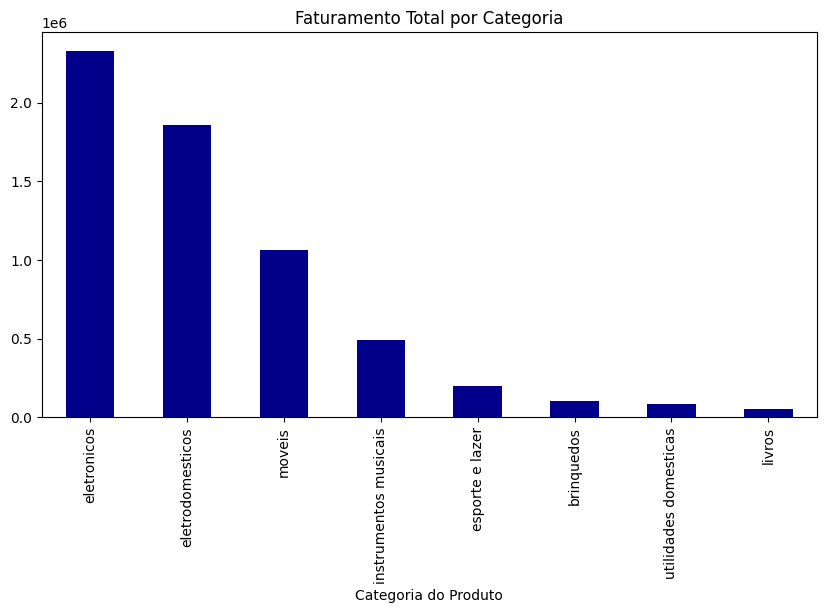

In [9]:
# 1. Agrupando por categoria e somando o faturamento
faturamento_por_categoria = df_completo.groupby('Categoria do Produto')['Faturamento'].sum().sort_values(ascending=False)

# 2. Agrupando por categoria e contando a quantidade de itens vendidos
quantidade_por_categoria = df_completo.groupby('Categoria do Produto')['Produto'].count().sort_values(ascending=False)

# 3. Exibindo os resultados
print("💰 FATURAMENTO POR CATEGORIA:")
print(faturamento_por_categoria.map('R$ {:,.2f}'.format))
print("\n📦 QUANTIDADE VENDIDA POR CATEGORIA:")
print(quantidade_por_categoria)

# 4. Criando um gráfico visual para facilitar a análise
faturamento_por_categoria.plot(kind='bar', figsize=(10,5), color='darkblue', title='Faturamento Total por Categoria')

# 3. Média de Avaliação das Lojas


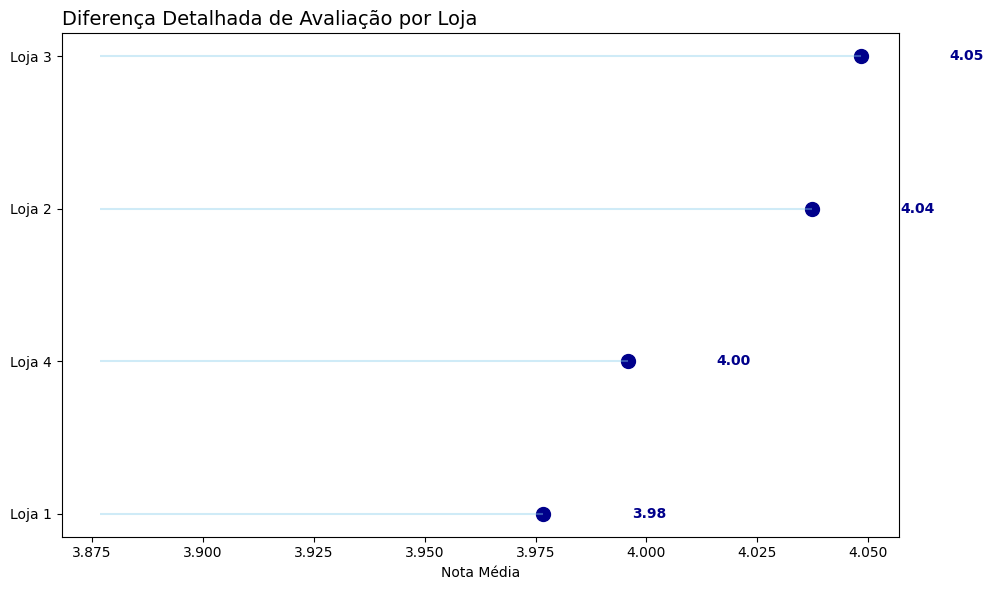

In [11]:
import matplotlib.pyplot as plt

# 1. Calculando a média (garantindo que os dados estão prontos)
df_com_unidades = pd.concat([loja, loja2, loja3, loja4], ignore_index=True)
df_com_unidades['Unidade'] = ['Loja 1']*len(loja) + ['Loja 2']*len(loja2) + ['Loja 3']*len(loja3) + ['Loja 4']*len(loja4)
media_notas = df_com_unidades.groupby('Unidade')['Avaliação da compra'].mean().sort_values()

# 2. Criando o Lollipop Chart
plt.figure(figsize=(10,6))
my_range = range(1, len(media_notas.index) + 1)

# A linha vertical
plt.hlines(y=my_range, xmin=media_notas.min() - 0.1, xmax=media_notas.values, color='skyblue', alpha=0.4)

# O ponto na ponta (onde a cor muda conforme a nota)
plt.scatter(media_notas.values, my_range, color='darkblue', s=100, alpha=1)

# Adicionando os nomes das lojas e os valores
plt.yticks(my_range, media_notas.index)
plt.title("Diferença Detalhada de Avaliação por Loja", loc='left', fontsize=14)
plt.xlabel('Nota Média')

# Colocando o valor exato ao lado do ponto para mostrar a diferença
for i, v in enumerate(media_notas.values):
    plt.text(v + 0.02, i + 1, f"{v:.2f}", color='darkblue', va='center', fontweight='bold')

plt.tight_layout()
plt.show()


# 4. Produtos Mais e Menos Vendidos

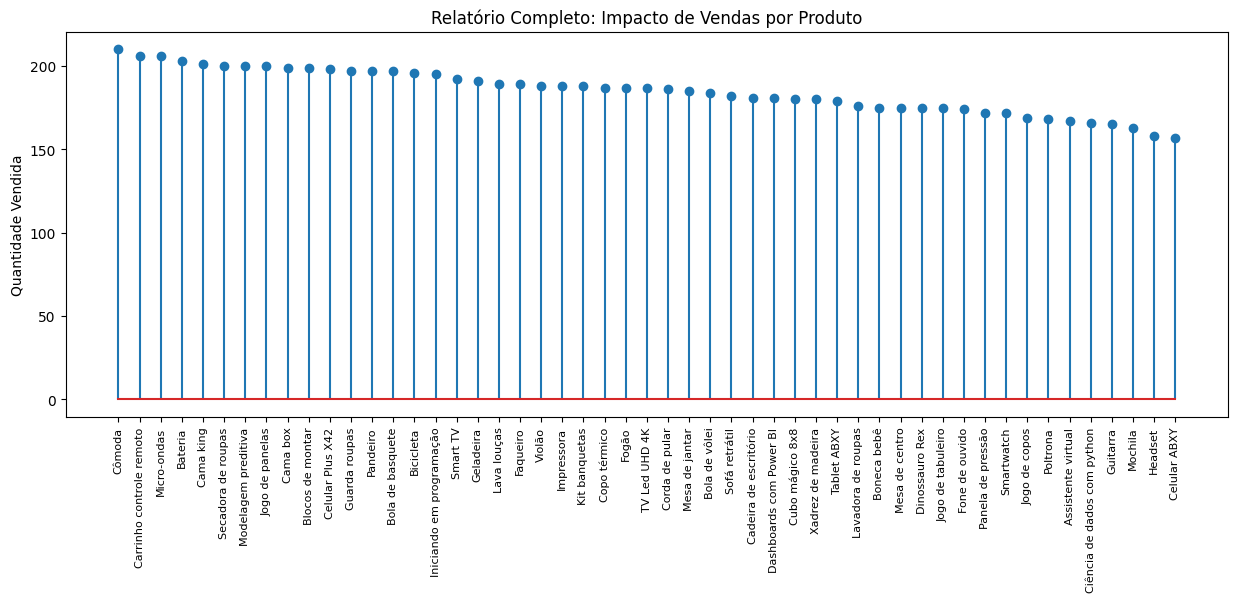

Produto
Cômoda                         210
Carrinho controle remoto       206
Micro-ondas                    206
Bateria                        203
Cama king                      201
Secadora de roupas             200
Modelagem preditiva            200
Jogo de panelas                200
Cama box                       199
Blocos de montar               199
Celular Plus X42               198
Guarda roupas                  197
Pandeiro                       197
Bola de basquete               197
Bicicleta                      196
Iniciando em programação       195
Smart TV                       192
Geladeira                      191
Lava louças                    189
Faqueiro                       189
Violão                         188
Impressora                     188
Kit banquetas                  188
Copo térmico                   187
Fogão                          187
TV Led UHD 4K                  187
Corda de pular                 186
Mesa de jantar                 185
Bola de vôle

In [26]:
import matplotlib.pyplot as plt

# 1. Dados completos
vendas = df_completo['Produto'].value_counts()

# 2. Gráfico de "Picos de Energia"
plt.figure(figsize=(15, 5))
plt.stem(vendas.index, vendas.values) # O comando 'stem' cria as linhas de "raio"

plt.xticks(rotation=90, fontsize=8)
plt.title("Relatório Completo: Impacto de Vendas por Produto")
plt.ylabel("Quantidade Vendida")
plt.show()

# 3. Lista completa logo abaixo
print(vendas)

# 5. Frete Médio por Loja

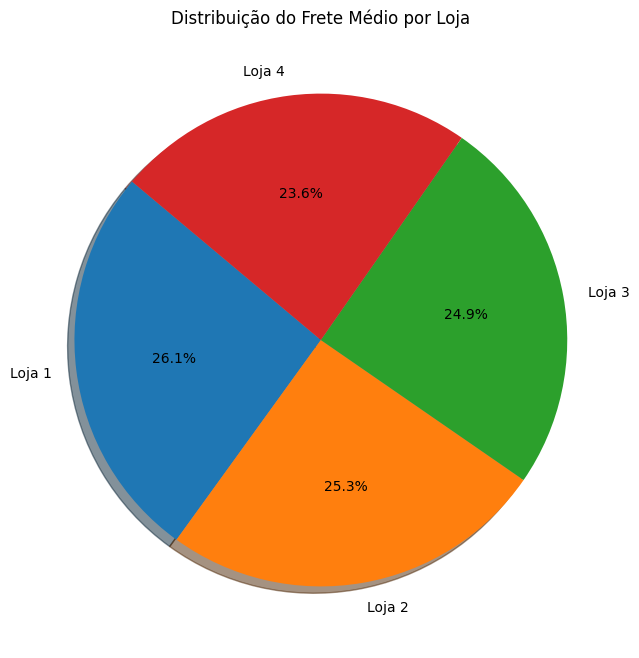

💰 VALORES REAIS DO FRETE MÉDIO:
Unidade
Loja 1    34.691805
Loja 2    33.621941
Loja 3    33.074464
Loja 4    31.278997
Name: Frete, dtype: float64


In [27]:
import matplotlib.pyplot as plt

# 1. Calculando a média de frete por unidade
frete_medio = df_com_unidades.groupby('Unidade')['Frete'].mean()

# 2. Gráfico de Pizza (Curto e limpo)
plt.figure(figsize=(8, 8))
plt.pie(frete_medio, labels=frete_medio.index, autopct='%1.1f%%', startangle=140, shadow=True)

plt.title('Distribuição do Frete Médio por Loja')
plt.show()

# 3. Relatório em texto logo abaixo
print("💰 VALORES REAIS DO FRETE MÉDIO:")
print(frete_medio)

           **Relatorio**
Relatório de Desempenho: Unidade Loja 1
1. **Diagnóstico de Desempenho**
Ao analisar o cruzamento das métricas fornecidas, a Loja 1 destaca-se negativamente em comparação com as outras três unidades da rede. Ela é considerada a operação menos eficiente no momento.

A. Experiência do Cliente (Avaliações)
Nota: **3.98**

Status: Pior da rede.

Análise: É a única loja que ficou abaixo da média **4.0.** Isso indica que há problemas na jornada de compra, que podem variar desde o atendimento até o tempo de entrega ou qualidade do produto recebido.

B. Eficiência Logística (Frete)
Custo Médio: R$ **34,69**

Status: Custo mais alto da rede.

Análise: O custo de frete na Loja 1 é aproximadamente **11%** superior ao da Loja 4.

Impacto no Lucro: Como o custo de frete é um gasto direto, a Loja 1 retém menos lucro por cada item vendido, mesmo que o preço de venda seja igual ao das outras lojas.

2. Por que a Loja 1 é a "Pior"?
O problema da Loja 1 é o efeito cascata:

Ela gasta mais para entregar (Frete de **R$ 34,69**).

Geralmente, fretes mais caros estão associados a transportadoras mais lentas ou regiões de difícil acesso, o que gera frustração.

Com este diagnostico recomento ao meu cliente Sr,Joao vende aloja 1 para abri capital par outros envestimento.